# Data Mining Final Project — Journal Finder
**Geliştirilmiş Versiyon**

This notebook:
- Combines Summary + Keyword + Subject resources
- Compares multiple models (Naive Bayes, Logistic Regression, LinearSVC)
- Determines the optimal number of clusters with Elbow + Silhouette
- Applies cross-validation
- Performs t-SNE visualization
- Generates WordCloud and interactive charts
- Provides user interface with ipywidgets

## 0. Installing Libraries

In [ ]:
!pip3 install wordcloud plotly scikit-learn nltk beautifulsoup4 ipywidgets
!pip3 install nbformat --upgrade

import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from IPython.display import display, HTML

# NLTK verilerini indir
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ Tüm kütüphaneler başarıyla yüklendi.')


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
✅ Tüm kütüphaneler başarıyla yüklendi.


## 1. Data Uploading and Merging

In [ ]:
academic_record  = pd.read_csv('AcademicRecord.csv')
abstracts        = pd.read_csv('AcademicRecordAbstract.csv')
publications     = pd.read_csv('Publication.csv')

keywords         = pd.read_csv('AcademicRecordKeyword.csv')      
keyword_names    = pd.read_csv('AcademicKeyword.csv')           
kw_plus          = pd.read_csv('AcademicRecordKeywordPlus.csv') 
kw_plus_names    = pd.read_csv('AcademicKeywordPlus.csv')       
subjects         = pd.read_csv('AcademicRecordSubject.csv')     
subject_names    = pd.read_csv('AcademicSubject.csv')         

for df in [academic_record, abstracts, publications, keywords, keyword_names,
           kw_plus, kw_plus_names, subjects, subject_names]:
    df.columns = df.columns.str.strip()

print('Tablolar yüklendi:')
print(f'  AcademicRecord    : {len(academic_record):,} satır')
print(f'  Abstracts         : {len(abstracts):,} satır')
print(f'  Publications      : {len(publications):,} satır')
print(f'  Keywords          : {len(keywords):,} satır')
print(f'  KeywordPlus       : {len(kw_plus):,} satır')
print(f'  Subjects          : {len(subjects):,} satır')

Tablolar yüklendi:
  AcademicRecord    : 23,801 satır
  Abstracts         : 23,061 satır
  Publications      : 466 satır
  Keywords          : 101,769 satır
  KeywordPlus       : 83,797 satır
  Subjects          : 86,033 satır


In [3]:
# --- Makale + Özet + Dergi ---
df = pd.merge(academic_record, abstracts,
              left_on='AcademicRecordID', right_on='AcademicRecordId')
df = pd.merge(df, publications,
              left_on='PublicationId', right_on='PublicationID')
df = df[['AcademicRecordID', 'AbstractText', 'Name']].rename(columns={'Name': 'JournalName'})

# --- Yazar Keyword'lerini birleştir ---
kw_merged = pd.merge(keywords, keyword_names, left_on='AcademicKeywordId', right_on='AcademicKeywordID')
kw_grouped = kw_merged.groupby('AcademicRecordId')['Name'].apply(lambda x: ' '.join(x)).reset_index()
kw_grouped.columns = ['AcademicRecordID', 'AuthorKeywords']
df = pd.merge(df, kw_grouped, on='AcademicRecordID', how='left')

# --- WoS KeywordPlus'ları birleştir ---
kwp_merged = pd.merge(kw_plus, kw_plus_names, left_on='AcademicKeywordPlusId', right_on='AcademicKeywordPlusID')
kwp_grouped = kwp_merged.groupby('AcademicRecordId')['Name'].apply(lambda x: ' '.join(x)).reset_index()
kwp_grouped.columns = ['AcademicRecordID', 'KeywordPlus']
df = pd.merge(df, kwp_grouped, on='AcademicRecordID', how='left')

# --- WoS Subject'leri birleştir ---
sub_merged = pd.merge(subjects, subject_names, left_on='AcademicSubjectId', right_on='AcademicSubjectID')
sub_grouped = sub_merged.groupby('AcademicRecordId')['NameEn'].apply(lambda x: ' '.join(x)).reset_index()
sub_grouped.columns = ['AcademicRecordID', 'Subjects']
df = pd.merge(df, sub_grouped, on='AcademicRecordID', how='left')

# --- Eksik değerleri boş stringle doldur ---
for col in ['AbstractText', 'AuthorKeywords', 'KeywordPlus', 'Subjects']:
    df[col] = df[col].fillna('')

# --- Zenginleştirilmiş tam metin ---
# Abstract ağırlıklı, keyword ve subject alanlar destek verir
df['RichText'] = (df['AbstractText'] + ' ' +
                  df['AuthorKeywords'] + ' ' + df['AuthorKeywords'] +   # 2x ağırlık
                  df['KeywordPlus']    + ' ' +
                  df['Subjects']       + ' ' + df['Subjects'])           # 2x ağırlık

print(f'\n✅ Birleştirme tamamlandı. Toplam {len(df):,} makale.')
df.head(3)


✅ Birleştirme tamamlandı. Toplam 23,061 makale.


,AcademicRecordID,AbstractText,JournalName,AuthorKeywords,KeywordPlus,Subjects,RichText
0,88652,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS,algorithms artificial intelligence genetic alg...,GENETIC ALGORITHM MULTICRITERIA OPTIMIZATION S...,"Computer Science, Theory & Methods Computer Sc...",<p>After using evolutionary techniques for sin...
1,88653,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS,query optimization query execution client-serv...,DATABASE-SYSTEMS DATA REPLICATION PERFORMANCE ...,"Computer Science, Theory & Methods Computer Sc...",<p>Distributed data processing is becoming a r...
2,88654,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS,defeasible argumentation argumentative systems...,IMPLEMENTATION FRAMEWORK,"Computer Science, Theory & Methods Computer Sc...",<p>Logical models of argument formalize common...


## 2. Text Preprocessing

In [4]:
stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess(text: str) -> str:
    """HTML temizleme → küçük harf → sadece harf → stopword → lemma"""
    if not isinstance(text, str) or not text.strip():
        return ''
    # HTML etiketleri
    text = BeautifulSoup(text, 'html.parser').get_text()
    # Sadece harfler
    text = re.sub(r'[^a-zA-Z\s]', ' ', text).lower()
    # Stopword + kısa kelimeler
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    # Lemmatization
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

print('Metin ön işleme başlıyor...')
df['Clean'] = df['RichText'].apply(preprocess)
print(f'✅ Tamamlandı. Ortalama kelime sayısı: {df["Clean"].str.split().str.len().mean():.0f}')
df.head(3)

Metin ön işleme başlıyor...
✅ Tamamlandı. Ortalama kelime sayısı: 145


,AcademicRecordID,AbstractText,JournalName,AuthorKeywords,KeywordPlus,Subjects,RichText,Clean
0,88652,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS,algorithms artificial intelligence genetic alg...,GENETIC ALGORITHM MULTICRITERIA OPTIMIZATION S...,"Computer Science, Theory & Methods Computer Sc...",<p>After using evolutionary techniques for sin...,using evolutionary technique single objective ...
1,88653,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS,query optimization query execution client-serv...,DATABASE-SYSTEMS DATA REPLICATION PERFORMANCE ...,"Computer Science, Theory & Methods Computer Sc...",<p>Distributed data processing is becoming a r...,distributed data processing becoming reality b...
2,88654,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS,defeasible argumentation argumentative systems...,IMPLEMENTATION FRAMEWORK,"Computer Science, Theory & Methods Computer Sc...",<p>Logical models of argument formalize common...,logical model argument formalize commonsense r...


## 3. Feature Extraction (TF-IDF)

In [5]:
tfidf = TfidfVectorizer(
    max_features=10000,   # Daha fazla özellik
    ngram_range=(1, 2),   # Unigram + Bigram
    sublinear_tf=True,    # log(TF) — büyük değerleri bastırır
    min_df=2              # En az 2 makalede geçen terimler
)

X = tfidf.fit_transform(df['Clean'])
y = df['JournalName']

print(f'TF-IDF matris boyutu : {X.shape}')
print(f'Toplam dergi sayısı  : {y.nunique()}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Eğitim seti          : {X_train.shape[0]:,} örnek')
print(f'Test seti            : {X_test.shape[0]:,} örnek')

TF-IDF matris boyutu : (23061, 10000)
Toplam dergi sayısı  : 455
Eğitim seti          : 18,448 örnek
Test seti            : 4,613 örnek


## 4. Model Comparison

In [ ]:
# ----- Helper function -----
def top5_accuracy(model, X_data, y_true, has_proba=True):
    """Top-5 doğruluk hesaplar"""
    if has_proba:
        probs = model.predict_proba(X_data)
    else:
        probs = model.decision_function(X_data)
    top5 = np.argsort(probs, axis=1)[:, -5:]
    classes = model.classes_
    y_list  = list(y_true)
    hit = sum(y_list[i] in classes[top5[i]] for i in range(len(y_list)))
    return hit / len(y_list)

def evaluate(name, model, has_proba=True):
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    top1     = accuracy_score(y_test, y_pred)
    top5     = top5_accuracy(model, X_test, y_test, has_proba)
    f1_mac   = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    f1_wei   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    print(f'  {name:<28}  Top-1={top1:.3f}  Top-5={top5:.3f}  F1(mac)={f1_mac:.3f}  F1(wei)={f1_wei:.3f}')
    return {'model': model, 'name': name, 'top1': top1, 'top5': top5,
            'f1_mac': f1_mac, 'f1_wei': f1_wei, 'has_proba': has_proba}

print('Model karşılaştırması (test seti):')
print('-' * 75)

results = []

# 1. Naive Bayes (baseline)
results.append(evaluate('Naive Bayes', MultinomialNB(alpha=0.1)))

# 2. Logistic Regression
results.append(evaluate('Logistic Regression',
    LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial')))

# 3. LinearSVC (Calibrated — predict_proba için)
svc = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000))
results.append(evaluate('LinearSVC (Calibrated)', svc))

print('-' * 75)

# Pick best model
best_result = max(results, key=lambda r: r['top5'])
best_model  = best_result['model']
print(f'\n🏆 En iyi model: {best_result["name"]}  (Top-5={best_result["top5"]:.3f})')

Model karşılaştırması (test seti):
---------------------------------------------------------------------------
  Naive Bayes                   Top-1=0.553  Top-5=0.812  F1(mac)=0.446  F1(wei)=0.515
  Logistic Regression           Top-1=0.719  Top-5=0.931  F1(mac)=0.633  F1(wei)=0.705
  LinearSVC (Calibrated)        Top-1=0.732  Top-5=0.925  F1(mac)=0.666  F1(wei)=0.724
---------------------------------------------------------------------------

🏆 En iyi model: Logistic Regression  (Top-5=0.931)


### 4a. Cross-Validation (5-Fold)

In [7]:
print('5-Fold Cross Validation (Logistic Regression)...')
cv_model = LogisticRegression(C=5, max_iter=1000, solver='lbfgs', multi_class='multinomial')
cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  CV Top-1 Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'  Fold sonuçları   : {[f"{s:.3f}" for s in cv_scores]}')

5-Fold Cross Validation (Logistic Regression)...
  CV Top-1 Accuracy: 0.700 ± 0.025
  Fold sonuçları   : ['0.679', '0.720', '0.726', '0.712', '0.661']


### 4b. Model Comparison Chart

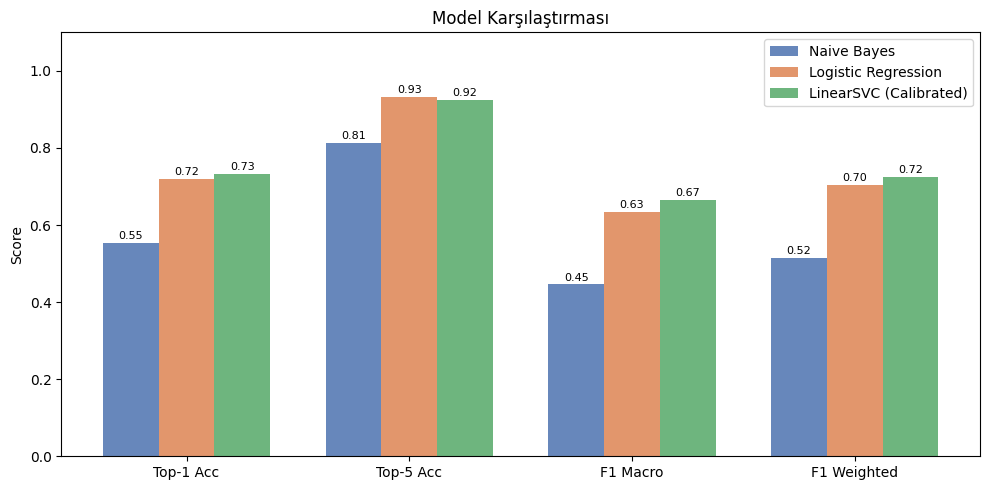

In [8]:
metrics = ['top1', 'top5', 'f1_mac', 'f1_wei']
labels  = ['Top-1 Acc', 'Top-5 Acc', 'F1 Macro', 'F1 Weighted']
x = np.arange(len(labels))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 5))
for i, r in enumerate(results):
    vals = [r[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=r['name'], color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Karşılaştırması')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 5. K-Means Clustering — Optimal k Selection

SVD boyut indirgeme (300 bileşen)...
  Açıklanan varyans oranı: 31.02%

Elbow + Silhouette hesaplanıyor (k=5..20)...
  k= 5  inertia=6,382  silhouette=0.0346
  k= 6  inertia=6,295  silhouette=0.0385
  k= 7  inertia=6,227  silhouette=0.0266
  k= 8  inertia=6,144  silhouette=0.0384
  k= 9  inertia=6,076  silhouette=0.0363
  k=10  inertia=6,022  silhouette=0.0392
  k=11  inertia=5,985  silhouette=0.0454
  k=12  inertia=5,926  silhouette=0.0400
  k=13  inertia=5,872  silhouette=0.0377
  k=14  inertia=5,827  silhouette=0.0519
  k=15  inertia=5,765  silhouette=0.0470
  k=16  inertia=5,748  silhouette=0.0437
  k=17  inertia=5,693  silhouette=0.0454
  k=18  inertia=5,655  silhouette=0.0513
  k=19  inertia=5,629  silhouette=0.0574
  k=20  inertia=5,575  silhouette=0.0551


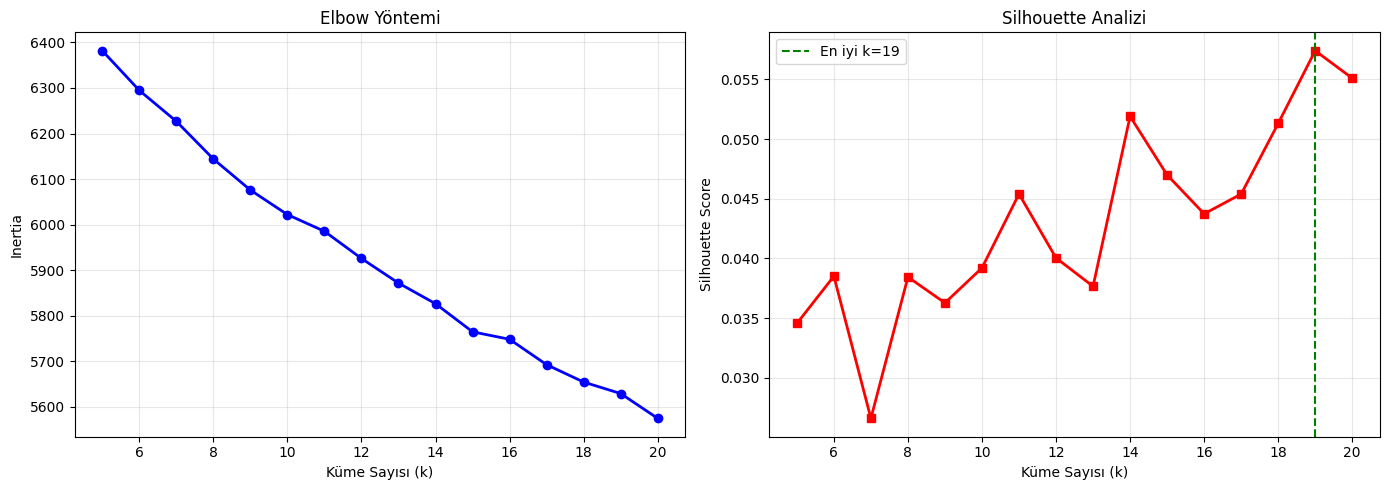


🏆 En iyi k = 19  (Silhouette=0.0574)


In [ ]:
print('SVD boyut indirgeme (300 bileşen)...')
svd = TruncatedSVD(n_components=300, random_state=42)
X_reduced = svd.fit_transform(X)
print(f'  Açıklanan varyans oranı: {svd.explained_variance_ratio_.sum():.2%}')

print('\nElbow + Silhouette hesaplanıyor (k=5..20)...')
k_range    = range(5, 21)
inertias   = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    sample_idx = np.random.choice(len(labels), min(2000, len(labels)), replace=False)
    sil = silhouette_score(X_reduced[sample_idx], labels[sample_idx])
    silhouettes.append(sil)
    print(f'  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}')

# Grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Küme Sayısı (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Yöntemi')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), silhouettes, 'rs-', linewidth=2)
ax2.set_xlabel('Küme Sayısı (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analizi')
ax2.grid(True, alpha=0.3)

best_k_idx = np.argmax(silhouettes)
best_k = list(k_range)[best_k_idx]
ax2.axvline(best_k, color='green', linestyle='--', label=f'En iyi k={best_k}')
ax2.legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()
print(f'\n🏆 En iyi k = {best_k}  (Silhouette={silhouettes[best_k_idx]:.4f})')

In [ ]:
# Final Clustering
OPTIMAL_K = best_k
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_reduced)

print(f'Kümeleme tamamlandı. k={OPTIMAL_K}')
print('\nKüme büyüklükleri:')
print(df['Cluster'].value_counts().sort_index().to_string())

Kümeleme tamamlandı. k=19

Küme büyüklükleri:
Cluster
0      263
1      459
2     2145
3     1950
4      744
5     1914
6      708
7      269
8     3328
9      581
10     114
11    2825
12     104
13     742
14     348
15    1024
16    1025
17    3024
18    1494


### 5a. Cluster Keywords


In [ ]:
feature_names = tfidf.get_feature_names_out()

cluster_keywords = {}
for cluster_id in range(OPTIMAL_K):
    mask = (df['Cluster'] == cluster_id).values 
    
    X_clus = X[mask]
    
    mean_tfidf = np.asarray(X_clus.mean(axis=0)).flatten()
    
    top_idx = mean_tfidf.argsort()[::-1][:12]
    
    keywords_list = [feature_names[i] for i in top_idx]
    cluster_keywords[cluster_id] = keywords_list
    
    print(f'Küme {cluster_id:2d} | {" | ".join(keywords_list[:8])}')

Küme  0 | education | educational | education educational | educational research | science education | application education | student | learning
Küme  1 | science library | library science | information science | library | system information | information | science information | science management
Küme  2 | hardware | hardware architecture | science hardware | architecture computer | architecture | computer | computer science | science
Küme  3 | science theory | theory method | method computer | theory | method | computer | computer science | science
Küme  4 | sensor | sensor network | wireless sensor | wireless | network | telecommunication | telecommunication computer | node
Küme  5 | science interdisciplinary | interdisciplinary application | interdisciplinary | application | science | computer | computer science | application computer
Küme  6 | telecommunication | channel | telecommunication engineering | engineering telecommunication | electronic telecommunication | engineering e

### 5b. t-SNE Interactive Visualization

In [ ]:
SAMPLE_N = min(3000, len(df))
sample_idx = np.random.choice(len(df), SAMPLE_N, replace=False)

print(f't-SNE hesaplanıyor ({SAMPLE_N} örnek)...')



tsne = TSNE(n_components=2, 
            random_state=42, 
            perplexity=40,
            learning_rate='auto', 
            init='pca') 

X_tsne = tsne.fit_transform(X_reduced[sample_idx])

tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Cluster': df['Cluster'].iloc[sample_idx].values.astype(str),
    'Journal': df['JournalName'].iloc[sample_idx].values,
    'Keywords': [', '.join(cluster_keywords[c][:3])
                 for c in df['Cluster'].iloc[sample_idx].values]
})

fig = px.scatter(
    tsne_df, x='x', y='y', color='Cluster',
    hover_data={'Journal': True, 'Keywords': True, 'x': False, 'y': False},
    title=f't-SNE Makale Konu Kümeleri (k={OPTIMAL_K}, n={SAMPLE_N})',
    width=900, height=650
)
fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.update_layout(legend_title_text='Küme')
fig.write_html('tsne_interactive.html')
fig.show()
print('💾 tsne_interactive.html olarak kaydedildi.')

t-SNE hesaplanıyor (3000 örnek)...


💾 tsne_interactive.html olarak kaydedildi.


### 5c. WordCloud — Her Küme İçin

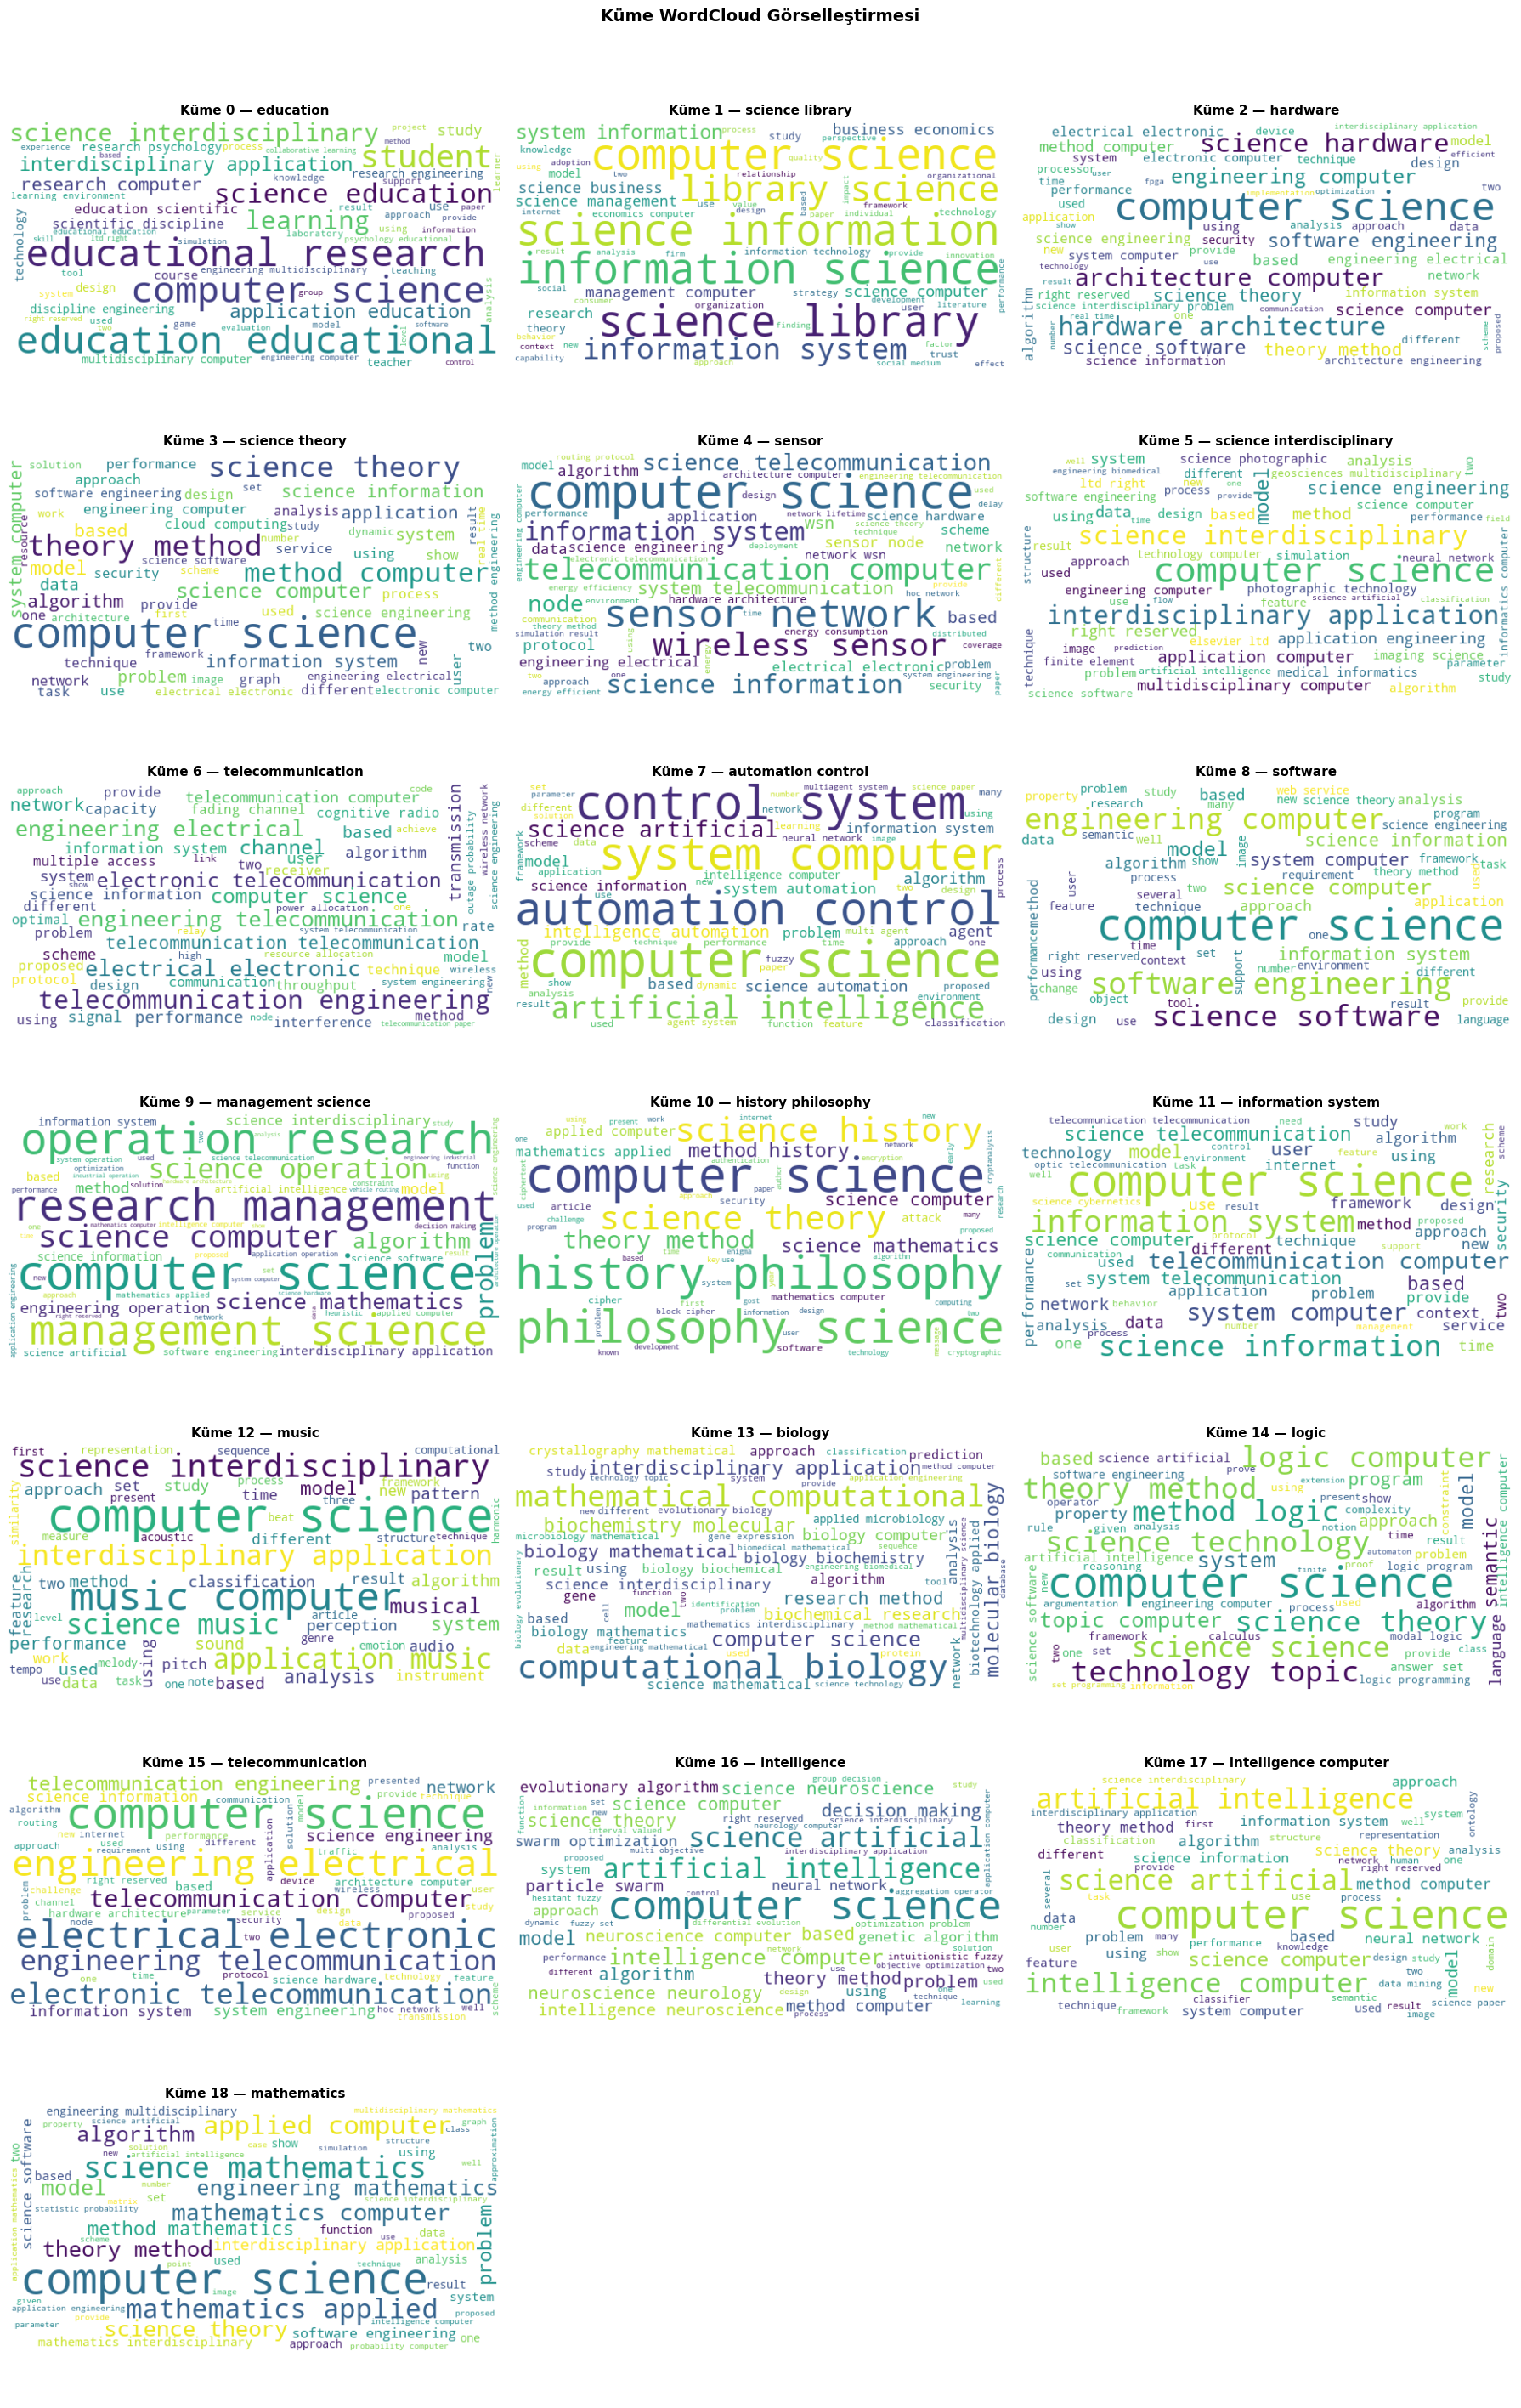

In [ ]:
cols = 3
rows = (OPTIMAL_K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for cluster_id in range(OPTIMAL_K):
    mask    = df['Cluster'] == cluster_id
    text    = ' '.join(df.loc[mask, 'Clean'])
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap='viridis', max_words=60).generate(text)
    axes[cluster_id].imshow(wc, interpolation='bilinear')
    axes[cluster_id].axis('off')
    top_kw = cluster_keywords[cluster_id][0]
    axes[cluster_id].set_title(f'Küme {cluster_id} — {top_kw}', fontsize=11, fontweight='bold')

for j in range(OPTIMAL_K, len(axes)):
    axes[j].axis('off')

plt.suptitle('Küme WordCloud Görselleştirmesi', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. User Interface — Top-5 Journal Finder

In [ ]:
def predict_top5_detailed(abstract_text: str, n=5):
    """Returns top-N journals from abstract documents."""
    cleaned = preprocess(abstract_text)
    if not cleaned.strip():
        return []
    vec = tfidf.transform([cleaned])
    probs = best_model.predict_proba(vec)[0]
    top_idx = np.argsort(probs)[::-1][:n]
    return [
        {'rank': i+1,
         'journal': best_model.classes_[idx],
         'confidence': probs[idx]}
        for i, idx in enumerate(top_idx)
    ]

# ----- Widget'lar -----
style = {'description_width': 'initial'}

header = widgets.HTML(
    value='<h2 style="color:#2c3e50;font-family:Arial">📚 Journal Finder — CS Article Recommender</h2>'
          '<p style="color:#555">Makale özetinizi girin, en uygun 5 dergiyi önerelim</p>'
)

abstract_input = widgets.Textarea(
    placeholder='Makale özetinizi buraya yapıştırın...',
    layout=widgets.Layout(width='95%', height='160px')
)

search_btn = widgets.Button(
    description='🔍  En İyi 5 Dergiyi Bul',
    button_style='primary',
    layout=widgets.Layout(width='250px', height='40px')
)

clear_btn = widgets.Button(
    description='🗑  Temizle',
    button_style='warning',
    layout=widgets.Layout(width='120px', height='40px')
)

output_area = widgets.Output()

def on_search(b):
    with output_area:
        output_area.clear_output()
        text = abstract_input.value.strip()
        if len(text) < 50:
            display(HTML('<p style="color:red">⚠️ Lütfen en az 50 karakter giriniz.</p>'))
            return

        preds = predict_top5_detailed(text)
        if not preds:
            display(HTML('<p style="color:red">❌ Tahmin yapılamadı.</p>'))
            return

        rows_html = ''
        bar_colors = ['#27ae60','#2980b9','#8e44ad','#e67e22','#e74c3c']
        for p in preds:
            pct   = p['confidence'] * 100
            color = bar_colors[p['rank'] - 1]
            rows_html += f"""
            <tr>
              <td style='padding:8px;font-weight:bold;color:{color}'>{p['rank']}</td>
              <td style='padding:8px'>{p['journal']}</td>
              <td style='padding:8px;width:200px'>
                <div style='background:#eee;border-radius:4px;height:18px'>
                  <div style='background:{color};width:{min(pct*3,100):.0f}%;height:18px;
                    border-radius:4px;text-align:right;padding-right:4px;
                    color:white;font-size:11px;line-height:18px'>{pct:.1f}%</div>
                </div>
              </td>
            </tr>"""

        html = f"""
        <div style='font-family:Arial;margin-top:10px'>
          <h3 style='color:#2c3e50'>🎯 Önerilen Dergiler</h3>
          <table border=0 cellspacing=0 style='border-collapse:collapse;width:100%;font-size:14px'>
            <thead>
              <tr style='background:#2c3e50;color:white'>
                <th style='padding:8px'>Sıra</th>
                <th style='padding:8px'>Dergi Adı</th>
                <th style='padding:8px'>Uyum Skoru</th>
              </tr>
            </thead>
            <tbody>{rows_html}</tbody>
          </table>
        </div>"""
        display(HTML(html))

def on_clear(b):
    abstract_input.value = ''
    output_area.clear_output()

search_btn.on_click(on_search)
clear_btn.on_click(on_clear)

display(
    header,
    abstract_input,
    widgets.HBox([search_btn, clear_btn]),
    output_area
)

HTML(value='<h2 style="color:#2c3e50;font-family:Arial">📚 Journal Finder — CS Article Recommender</h2><p style…

Textarea(value='', layout=Layout(height='160px', width='95%'), placeholder='Makale özetinizi buraya yapıştırın…

Output()

## 7. Küme Dağılımı — Dergi Bazlı Analiz

Küme başına baskın dergiler:



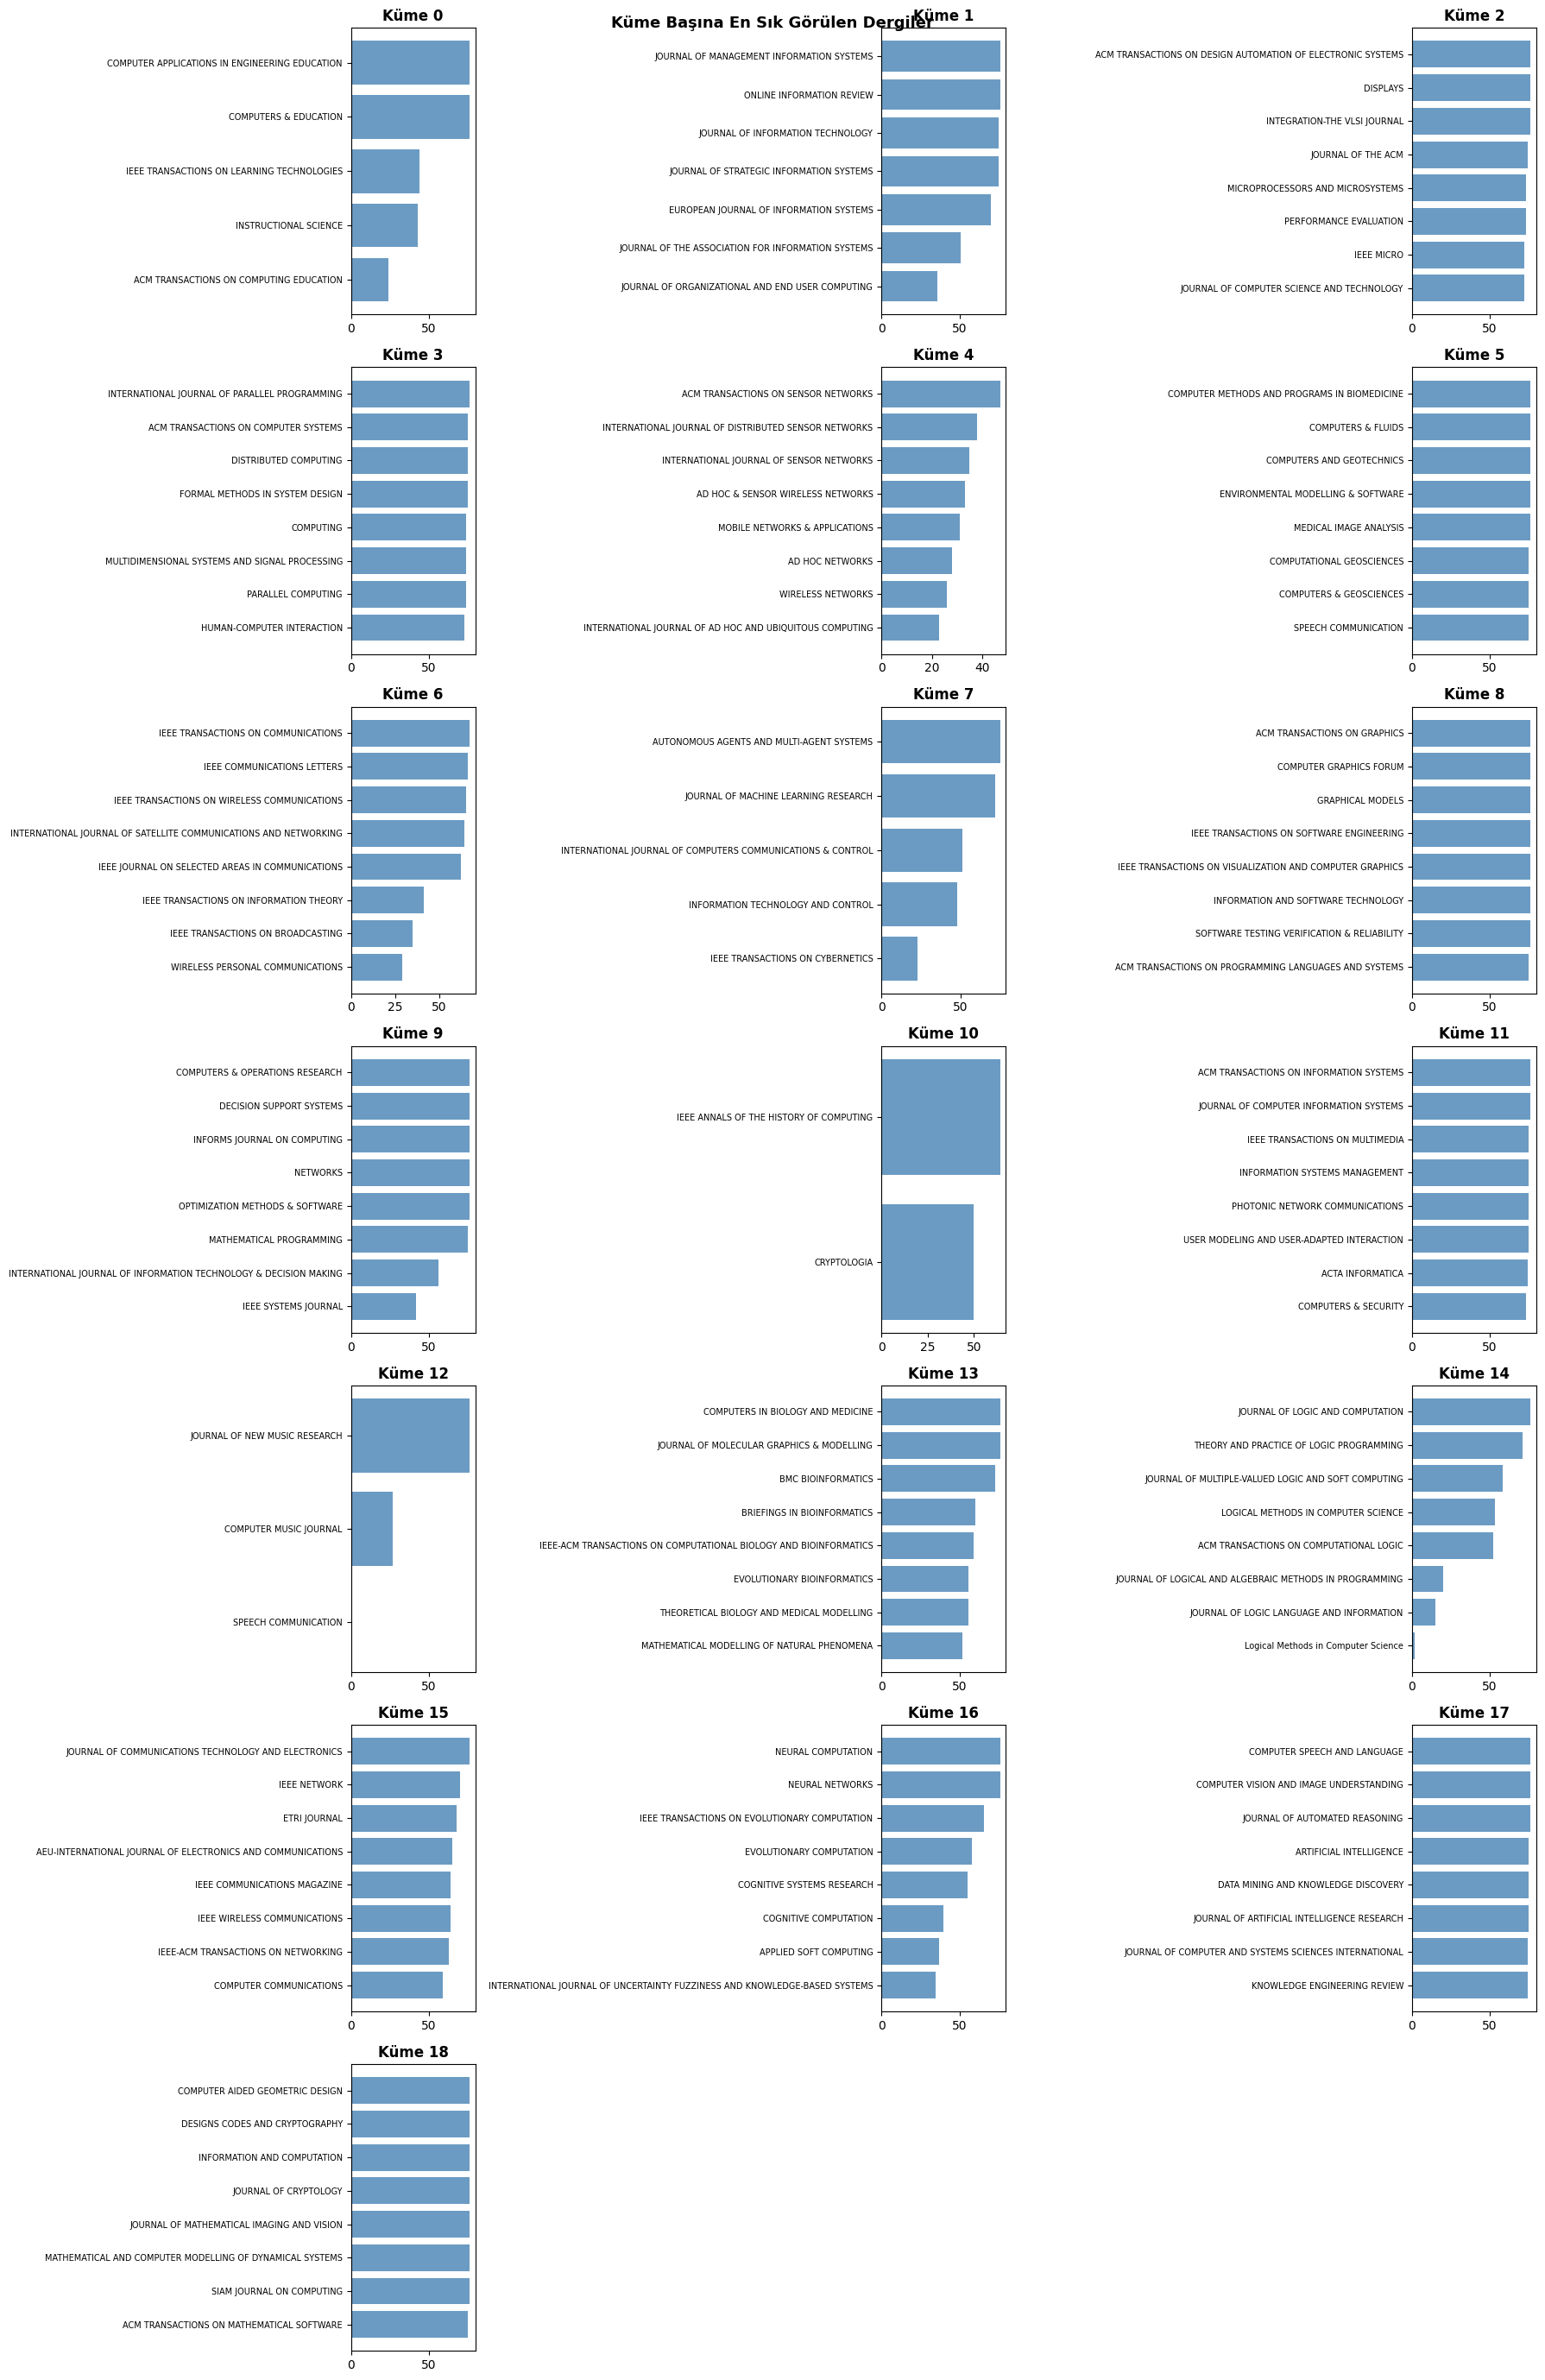

In [ ]:
print('Küme başına baskın dergiler:\n')
cluster_journal = df.groupby(['Cluster', 'JournalName']).size().reset_index(name='Count')

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

for cluster_id in range(OPTIMAL_K):
    cj = cluster_journal[cluster_journal['Cluster'] == cluster_id]
    cj = cj.nlargest(8, 'Count')
    axes[cluster_id].barh(cj['JournalName'], cj['Count'], color='steelblue', alpha=0.8)
    axes[cluster_id].set_title(f'Küme {cluster_id}', fontweight='bold')
    axes[cluster_id].invert_yaxis()
    axes[cluster_id].tick_params(axis='y', labelsize=7)

for j in range(OPTIMAL_K, len(axes)):
    axes[j].axis('off')

plt.suptitle('Küme Başına En Sık Görülen Dergiler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_journals.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Özet Rapor

In [19]:
print('=' * 60)
print('           PROJE SONUÇ ÖZETİ')
print('=' * 60)
print(f'  Toplam makale sayısı     : {len(df):,}')
print(f'  Toplam dergi sayısı      : {y.nunique()}')
print(f'  TF-IDF özellik sayısı    : {X.shape[1]:,}')
print()
print('  Model Performansları (Test Set):')
for r in results:
    print(f'    {r["name"]:<28}  Top-1={r["top1"]:.3f}  Top-5={r["top5"]:.3f}')
print(f'  5-Fold CV (Logistic Reg.)  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print()
print(f'  Optimal Küme Sayısı (k)  : {OPTIMAL_K}')
print(f'  Silhouette Score         : {silhouettes[best_k_idx]:.4f}')
print()

print('=' * 60)

           PROJE SONUÇ ÖZETİ
  Toplam makale sayısı     : 23,061
  Toplam dergi sayısı      : 455
  TF-IDF özellik sayısı    : 10,000

  Model Performansları (Test Set):
    Naive Bayes                   Top-1=0.553  Top-5=0.812
    Logistic Regression           Top-1=0.719  Top-5=0.931
    LinearSVC (Calibrated)        Top-1=0.732  Top-5=0.925
  5-Fold CV (Logistic Reg.)  : 0.700 ± 0.025

  Optimal Küme Sayısı (k)  : 19
  Silhouette Score         : 0.0574

